# Submission for Exercise 02
## Collaborators
- Friedrich Zeddies, 4207290
- Sebastian Metzler, 4204202
-  Till Frühauf, 4231789

## General Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split 
from sklearn.mixture import GaussianMixture
import time 
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

## Exercises
### Exercise 1


<div style="color: green; font-weight:
bold">

- Their encoder and decoder implementation is equivalent to the solution except for the layer number. They included the final layer that alters the hidden dimension to match the bottleneck size or output size as an extra layer and technically have one layer too much. This could be fixed by running the for loop with hidden layer size 'layers - 2' times.

- They stored the input variables for input_size, bottleneck-size etc. as properties of the Autoencoder class. This is not strictly necessary.

- The class also switches to a hardware accelerator (GPU) if available, which is a nice addition.

- The solution implements separate functions for encoder and decoder to combine them in a forward function and use them individually in ex.2. In this case, the forward function returns the encoded and decoded data points, which ends up with the same functionality.

- Overall, the foward and train_autoencoder function implementation is equivalent to the solution. 
In the training algorithm, they used the torch.utils.data.Dataloader function to sample input data in batches, which implements the same functionality as the explicit code in the solution.

</div>

In [2]:
class Autoencoder(nn.Module):
    def __init__(self, input_size, bottleneck_size=1, hidden_size=1, layers=1):
        super().__init__()
        self.input_size = input_size
        self.bottleneck_size = bottleneck_size
        self.hidden_size = hidden_size              # dim hidden layers
        self.layers = layers

        # inititalize encoder, create layers dynamically based on layer size
        
        enc_layers = []
        enc_layers.append(nn.Linear(self.input_size, self.hidden_size))
        enc_layers.append(nn.ReLU())
        if self.hidden_size > 1:
            for _ in range(self.layers - 1):
                enc_layers.append(nn.Linear(self.hidden_size, self.hidden_size))
                enc_layers.append(nn.ReLU())
        enc_layers.append(nn.Linear(self.hidden_size, self.bottleneck_size))

        self.encoder = nn.Sequential(*enc_layers)

        # mirror encoder
        dec_layers = []
        dec_layers.append(nn.Linear(self.bottleneck_size, self.hidden_size))
        dec_layers.append(nn.ReLU())
        if self.hidden_size > 1:
            for _ in range(self.layers-1):
                dec_layers.append(nn.Linear(self.hidden_size, self.hidden_size))
                dec_layers.append(nn.ReLU())
        dec_layers.append(nn.Linear(self.hidden_size, self.input_size))
        self.decoder = nn.Sequential(*dec_layers)

    # standard feed forward, but ensure both encoder and decoder output are accessible 
    def forward(self, data):
        encoded = self.encoder(data)
        decoded = self.decoder(encoded)
        return encoded, decoded


# accelerate if possible (CUDE; mps, ...)
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# --- Training loop --- (basicaally template for other one too!)
def train_autoecoder(model, train_data, num_epochs, num_batches=32, learning_rate=0.001):
    # convert all data to torch.tensor object if it has not happened, put to device
    if not isinstance(train_data, torch.Tensor):
        train_data = torch.Tensor(train_data)
    train_data.to(device)
    
    # Data Loader for minibatching, shuffle too
    data_loader = DataLoader(train_data, batch_size=num_batches, shuffle=True)
    
    model.to(device)

    # for now: MSE, later add MMD2
    loss_fct = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    #accunulate losses
    losses = []

    # iterate over epochs, calculate loss, optimize using grad descent, avg losses
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for batch in data_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            _, decoded = model(batch)
            loss = loss_fct(decoded, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch.size(0)

        avg_loss = epoch_loss / len(train_data)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    return model, losses


Using cpu device


In [3]:
# generate, split and shuffle (larger data, good params for illustration)
X, y = datasets.make_moons(10000, random_state=42, noise=0.1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


<div style="color: green; font-weight:
bold">

Standardizing our data before training would have been more elegant. If the mean and variance of the data is very different from 0 and 1, respectively, model fitting can be impaired. 
However, with a mean of ~0.5 and variance of ~0.8 the deviations are not very big and training still worked without problems. 


AS in the solution, a good model with convergence of the loss per 10 epochs is shown below, before description of the hyperparameter testing.
</div>

In [4]:
# general autoencoder for fine 
model = Autoencoder(X.shape[1], 1, 32, 5)
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [5]:
epochs = 50
_, losses = train_autoecoder(model, X, epochs, num_batches=32)

Epoch 10/50, Loss: 0.0084
Epoch 20/50, Loss: 0.0070
Epoch 30/50, Loss: 0.0076
Epoch 40/50, Loss: 0.0061
Epoch 50/50, Loss: 0.0076


Text(0, 0.5, 'Loss MSE')

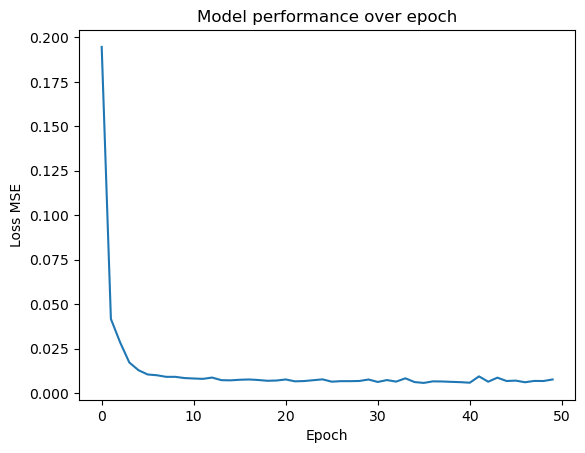

In [6]:
plt.plot(range(epochs), losses)
plt.title("Model performance over epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss MSE")

We can observe conversion to relatively stable loss.

In [7]:
with torch.no_grad():
    # ensure we use float32 because MPS doesn't support float64
    encoded_val, decoded = model(torch.as_tensor(X_val, dtype=torch.float32, device=device))

# move the decoded tensor to CPU and convert to numpy
reconstructed = decoded.cpu().numpy()
reconstructed.shape

(2000, 2)

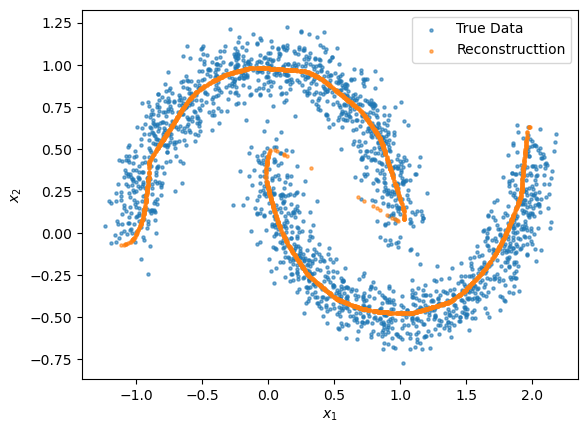

In [8]:
plt.scatter(X_val[:, 0], X_val[:, 1], label = "True Data", alpha=0.6, s=5)
plt.scatter(reconstructed[:, 0], reconstructed[:, 1], label = "Reconstructtion", alpha=0.6, s=5)
plt.xlabel(f"$x_1$")
plt.ylabel(f"$x_2$")
plt.legend()

The data generated by the AE is capturing the model fundamentals with the essential difference, that the points are lying on a line following the visible arcs of the data -  which is to be expected as the bottleneck of dimension 1 enforces the code to live in a subspace of the actual data dimension, a plane.

Down below, many hyperparameters have been thoroughly tested.

## Hyperparameter-Testing

<div style="color: green; font-weight:
bold">

The implementation of 1.1 is equivalent to the solution.
They visualise the results of each parameter test in terms of loss curves (every 10 epochs) and plots of the reconstructed vs. original data. They also give the mse mean and include time-consumption as a consideration. 
They end up with hyperparamters of `(input_dim=2, bottleneck=1, hidden_size=32, layers=5)` while training on about 50 epochs with standard minibatching and learning rate. 

</div>

In [9]:
# Helper for loss and reconstruction visuals
def plot_MSELoss_epoch(losses, epochs, label_str, ax=None,):
    if ax == None:
        fig, ax = plt.subplots(1, 1)
    ax.plot(range(epochs), losses)
    ax.set_title(label_str)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss MSE")


def plot_data_reconstruction(data, reconstruction, label_str, ax=None):
    if ax == None:
        fig, ax = plt.subplots(1, 1)
    ax.scatter(data[:, 0], data[:, 1], label = "True Data", alpha=0.6, s=5)
    ax.scatter(reconstruction[:, 0], reconstruction[:, 1], label = "Reconstructtion", alpha=0.6, s=5)
    ax.set_title(label_str)
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_1$")
    ax.legend()

---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=4), N_samples = 50 ----
Epoch 10/30, Loss: 0.5909
Epoch 20/30, Loss: 0.5432
Epoch 30/30, Loss: 0.5279
Time elapsed: 00:00.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=4), N_samples = 500 ----
Epoch 10/30, Loss: 0.0969
Epoch 20/30, Loss: 0.0579
Epoch 30/30, Loss: 0.0421
Time elapsed: 00:02.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=4), N_samples = 1000 ----
Epoch 10/30, Loss: 0.0342
Epoch 20/30, Loss: 0.0305
Epoch 30/30, Loss: 0.0265
Time elapsed: 00:03.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=4), N_samples = 5000 ----
Epoch 10/30, Loss: 0.0103
Epoch 20/30, Loss: 0.0074
Epoch 30/30, Loss: 0.0066
Time elapsed: 00:18.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=4), N_samples = 10000 ----
Epoch 10/30, Loss: 0.0073
Epoch 20/30, Loss: 0.0066
Epoch 30/30, Loss: 0.0067
Time elapsed: 00:36.




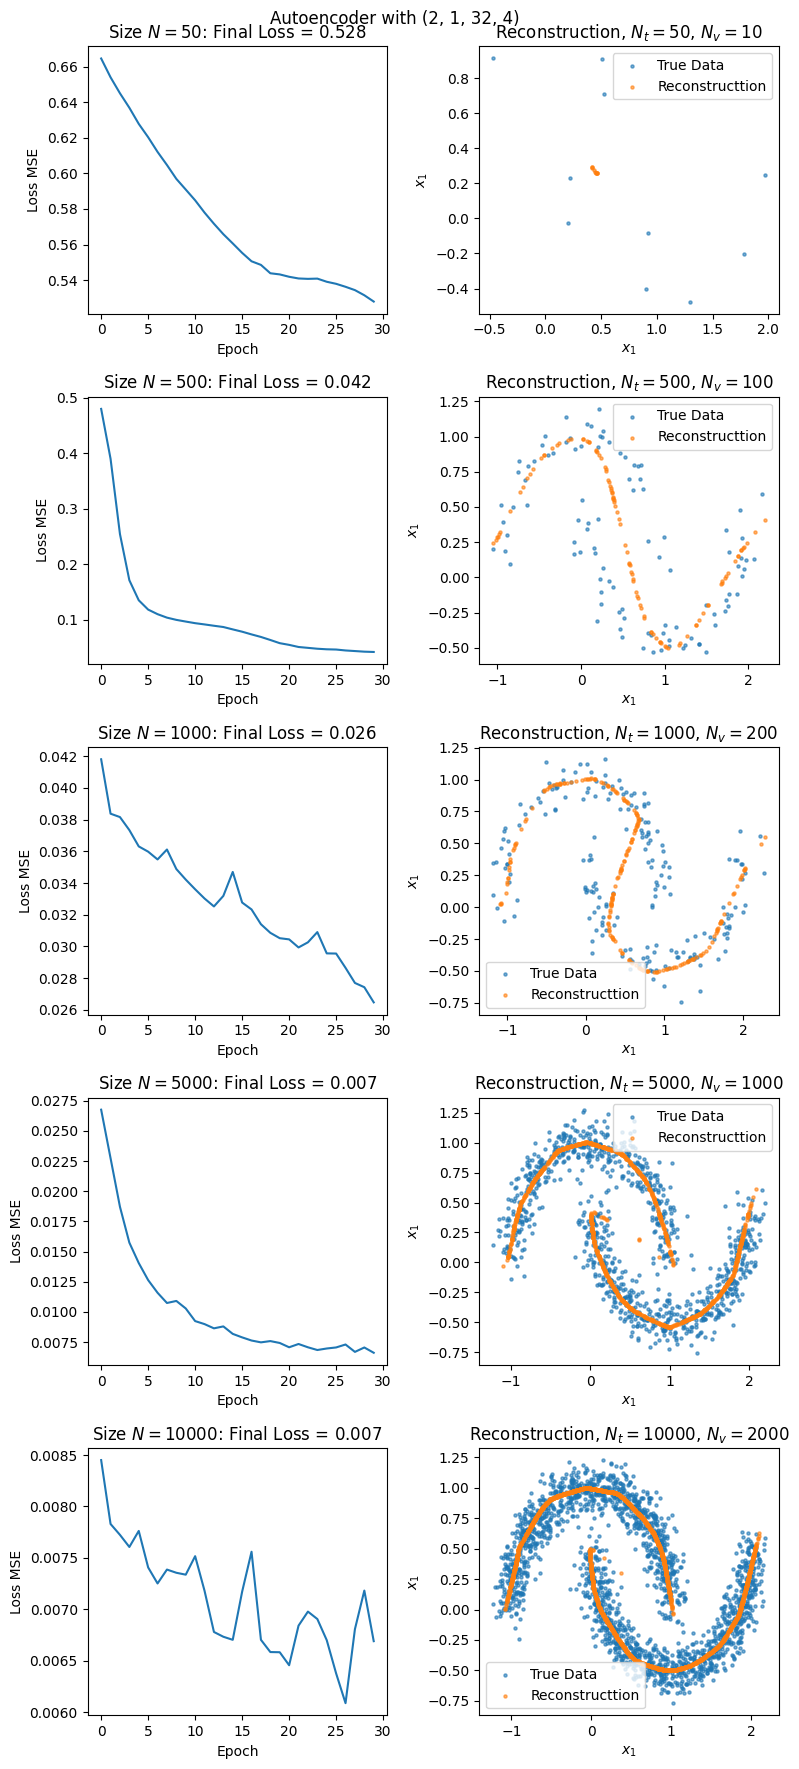

In [10]:
# test different data set sizes
N_samples = [50, 500, 1000, 5000, 10000]

# choose good, but not too expensive parameters
in_features=2
bottleneck_size=1 
hidden_size=32
hidden_layers=4
epochs = 30

# init model
model = Autoencoder(in_features, bottleneck_size, hidden_size, hidden_layers)

#viusuals
fig, axs = plt.subplots(5, 2, figsize =(8, 18))
fig.suptitle(f"Autoencoder with {(in_features, bottleneck_size, hidden_size, hidden_layers)}")

for i, size in enumerate(N_samples):
    # generate training and validation sets of size N_samples
    X, y = datasets.make_moons(size, random_state=42, noise=0.1)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # --- start trianing loop ---
    print(f"---- Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={hidden_size}, hidden_layers={hidden_layers}), N_samples = {size} ----")
    
    # get time (interesting)
    t_start = time.time()

    _, loss = train_autoecoder(model, X_train, epochs)

    t_end = time.time()
    elapsed = t_end - t_start
    dt = time.strftime('%M:%S', time.gmtime(elapsed))
    print(f"Time elapsed: {dt}.")

    # plot using helper
    plot_MSELoss_epoch(loss, epochs, f"Size $N={size}$: Final Loss = {np.round(loss[-1],3)}", axs[i, 0])

    # --- reconstruct and visualize ---
    with torch.no_grad():
        # use model on validation set and move reconstruction to cpu
        encoded_val, decoded = model(torch.as_tensor(X_val, dtype=torch.float32, device=device))
        reconstructed = decoded.cpu().numpy()

    # N for training set size, N_v for validation size (N_v = 0.2 * N), see split
    plot_data_reconstruction(X_val, reconstructed, 
                             f"Reconstruction, $N_t={size}$, $N_v = {int(size*0.2)}$", axs[i, 1])
    print("\n")
plt.tight_layout()
plt.show()
    

As expected, the size of the set improves the reconstruction significantly. Interestingly, the model finds somewhat close patterns at only 400 data points for training. The performance is best at 10k samples, but doubles in time consumption compared to 5000 samples, which also achieves good results. Therefore, 5k samples seems efficient and reasonable good.

---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=3), Epochs = 10 ----
Epoch 10/10, Loss: 0.0137
Time elapsed: 00:05.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=3), Epochs = 25 ----
Epoch 10/25, Loss: 0.0313
Epoch 20/25, Loss: 0.0116
Time elapsed: 00:13.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=3), Epochs = 50 ----
Epoch 10/50, Loss: 0.0135
Epoch 20/50, Loss: 0.0075
Epoch 30/50, Loss: 0.0074
Epoch 40/50, Loss: 0.0068
Epoch 50/50, Loss: 0.0064
Time elapsed: 00:26.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=3), Epochs = 100 ----
Epoch 10/100, Loss: 0.0266
Epoch 20/100, Loss: 0.0104
Epoch 30/100, Loss: 0.0097
Epoch 40/100, Loss: 0.0075
Epoch 50/100, Loss: 0.0072
Epoch 60/100, Loss: 0.0069
Epoch 70/100, Loss: 0.0069
Epoch 80/100, Loss: 0.0069
Epoch 90/100, Loss: 0.0065
Epoch 100/100, Loss: 0.0064
Time elapsed: 00:48.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hid

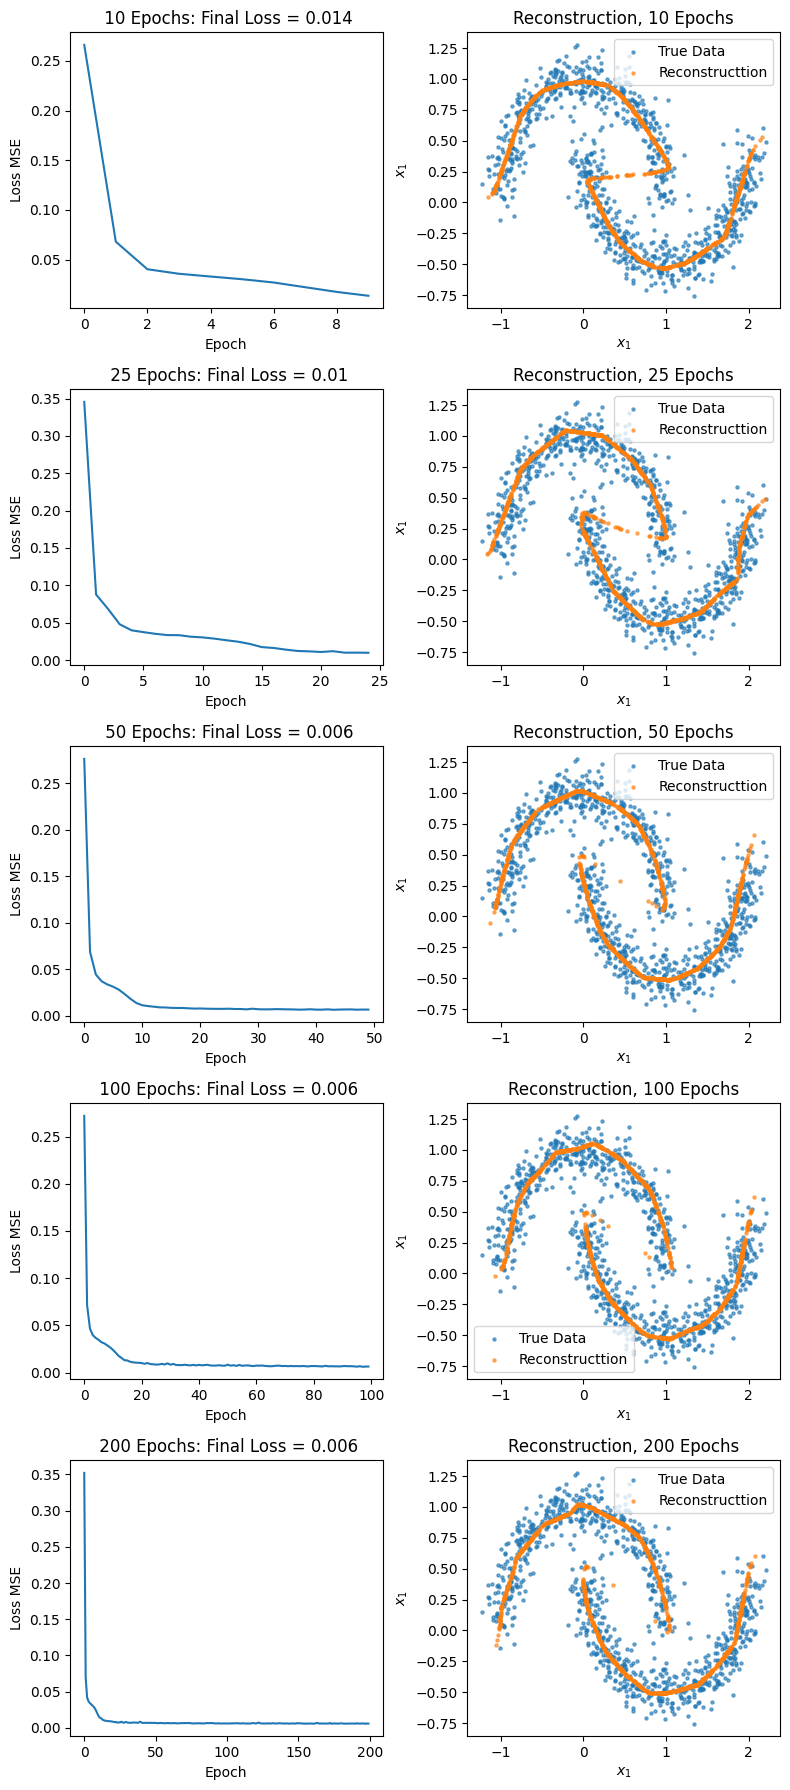

In [11]:
# Based on analysis, fix for now
X, y = datasets.make_moons(5000, random_state=42, noise=0.1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- EPOCHS ---
in_features=2
bottleneck_size=1 
hidden_size=32
hidden_layers=3

epochs = [10, 25, 50, 100, 200] 

fig, axs = plt.subplots(5, 2, figsize =(8, 18))

for i, epoch in enumerate(epochs):
    model_n = Autoencoder(in_features, bottleneck_size, hidden_size, hidden_layers)
    
    # --- start trianing loop ---
    print(f"---- Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={hidden_size}, hidden_layers={hidden_layers}), Epochs = {epoch} ----")
    
    # get time (interesting)
    t_start = time.time()

    _, loss = train_autoecoder(model_n, X_train, epoch)

    t_end = time.time()
    elapsed = t_end - t_start
    dt = time.strftime('%M:%S', time.gmtime(elapsed))
    print(f"Time elapsed: {dt}.")

    # plot using helper
    plot_MSELoss_epoch(loss, epoch, f" {epoch} Epochs: Final Loss = {np.round(loss[-1],3)}", axs[i, 0])

    # --- reconstruct and visualize ---
    with torch.no_grad():
        encoded_val, decoded = model_n(torch.as_tensor(X_val, dtype=torch.float32, device=device))
        reconstructed = decoded.cpu().numpy()

    plot_data_reconstruction(X_val, reconstructed, f"Reconstruction, {epoch} Epochs", axs[i, 1])
    print("\n")
plt.tight_layout()
plt.show()
    

Too few epochs do not allow the model to learn. To many are very time consuming. Both visually and by loss examniation, for easier purpose 50 epochs seem fine.

---- Trainig AE(in_size=2, bottleneck=1, hidden_size=16, hidden_layers=3) ----
Epoch 10/50, Loss: 0.0452
Epoch 20/50, Loss: 0.0327
Epoch 30/50, Loss: 0.0249
Epoch 40/50, Loss: 0.0158
Epoch 50/50, Loss: 0.0128
Time elapsed: 00:24.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=3) ----
Epoch 10/50, Loss: 0.0277
Epoch 20/50, Loss: 0.0101
Epoch 30/50, Loss: 0.0083
Epoch 40/50, Loss: 0.0075
Epoch 50/50, Loss: 0.0068
Time elapsed: 00:24.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=64, hidden_layers=3) ----
Epoch 10/50, Loss: 0.0089
Epoch 20/50, Loss: 0.0072
Epoch 30/50, Loss: 0.0066
Epoch 40/50, Loss: 0.0063
Epoch 50/50, Loss: 0.0059
Time elapsed: 00:24.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=128, hidden_layers=3) ----
Epoch 10/50, Loss: 0.0088
Epoch 20/50, Loss: 0.0082
Epoch 30/50, Loss: 0.0066
Epoch 40/50, Loss: 0.0067
Epoch 50/50, Loss: 0.0065
Time elapsed: 00:25.




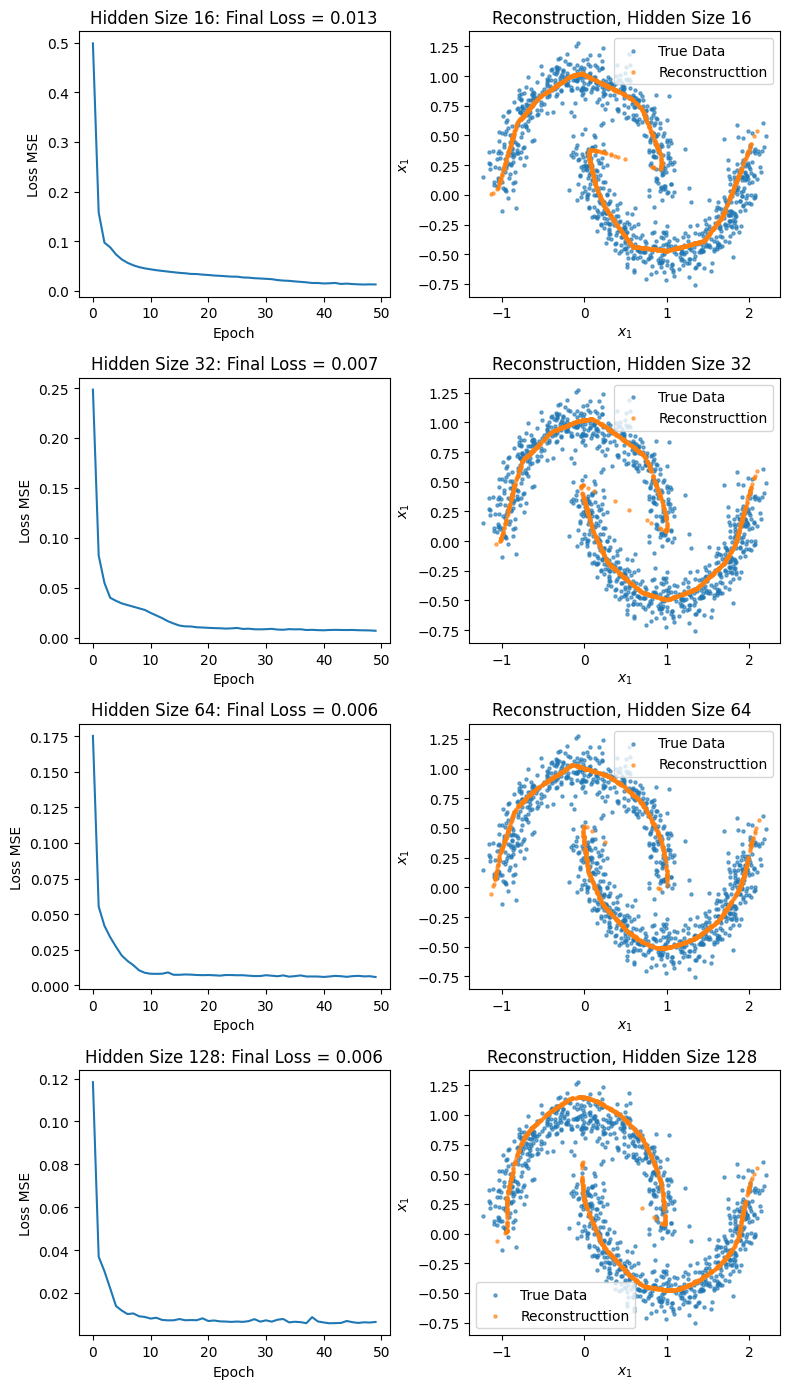

In [12]:
# --- HIDDEN_SIZE ---
in_features=2
bottleneck_size=1 
hidden_sizes=[16, 32, 64, 128]
hidden_layers=3

epochs = 50

fig, axs = plt.subplots(4, 2, figsize =(8, 14))

for i, size in enumerate(hidden_sizes):
    model_n = Autoencoder(in_features, bottleneck_size, size, hidden_layers)
    
    # --- start trianing loop ---
    print(f"---- Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={size}, hidden_layers={hidden_layers}) ----")
    
    # get time (interesting)
    t_start = time.time()

    _, loss = train_autoecoder(model_n, X_train, epochs)

    t_end = time.time()
    elapsed = t_end - t_start
    dt = time.strftime('%M:%S', time.gmtime(elapsed))
    print(f"Time elapsed: {dt}.")

    # plot using helper
    plot_MSELoss_epoch(loss, epochs, f"Hidden Size {size}: Final Loss = {np.round(loss[-1],3)}", axs[i, 0])

    # --- reconstruct and visualize ---
    with torch.no_grad():
        encoded_val, decoded = model_n(torch.as_tensor(X_val, dtype=torch.float32, device=device))
        reconstructed = decoded.cpu().numpy()

    plot_data_reconstruction(X_val, reconstructed, f"Reconstruction, Hidden Size {size} ", axs[i, 1])
    print("\n")
plt.tight_layout()
plt.show()

The more neurons in a layer, the more detail we could expect. However, already with hidden size 32 we see more then decent results and can use that, as $dim(x)=2<<32$ already. However, we can and need to adjust if the input dimension grows.

---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=1) ----
Epoch 10/50, Loss: 0.0395
Epoch 20/50, Loss: 0.0345
Epoch 30/50, Loss: 0.0307
Epoch 40/50, Loss: 0.0277
Epoch 50/50, Loss: 0.0244
Time elapsed: 00:16.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=3) ----
Epoch 10/50, Loss: 0.0190
Epoch 20/50, Loss: 0.0089
Epoch 30/50, Loss: 0.0074
Epoch 40/50, Loss: 0.0070
Epoch 50/50, Loss: 0.0065
Time elapsed: 00:24.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
Epoch 10/50, Loss: 0.0221
Epoch 20/50, Loss: 0.0101
Epoch 30/50, Loss: 0.0076
Epoch 40/50, Loss: 0.0074
Epoch 50/50, Loss: 0.0067
Time elapsed: 01:18.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=8) ----
Epoch 10/50, Loss: 0.0275
Epoch 20/50, Loss: 0.0085
Epoch 30/50, Loss: 0.0073
Epoch 40/50, Loss: 0.0070
Epoch 50/50, Loss: 0.0066
Time elapsed: 00:42.




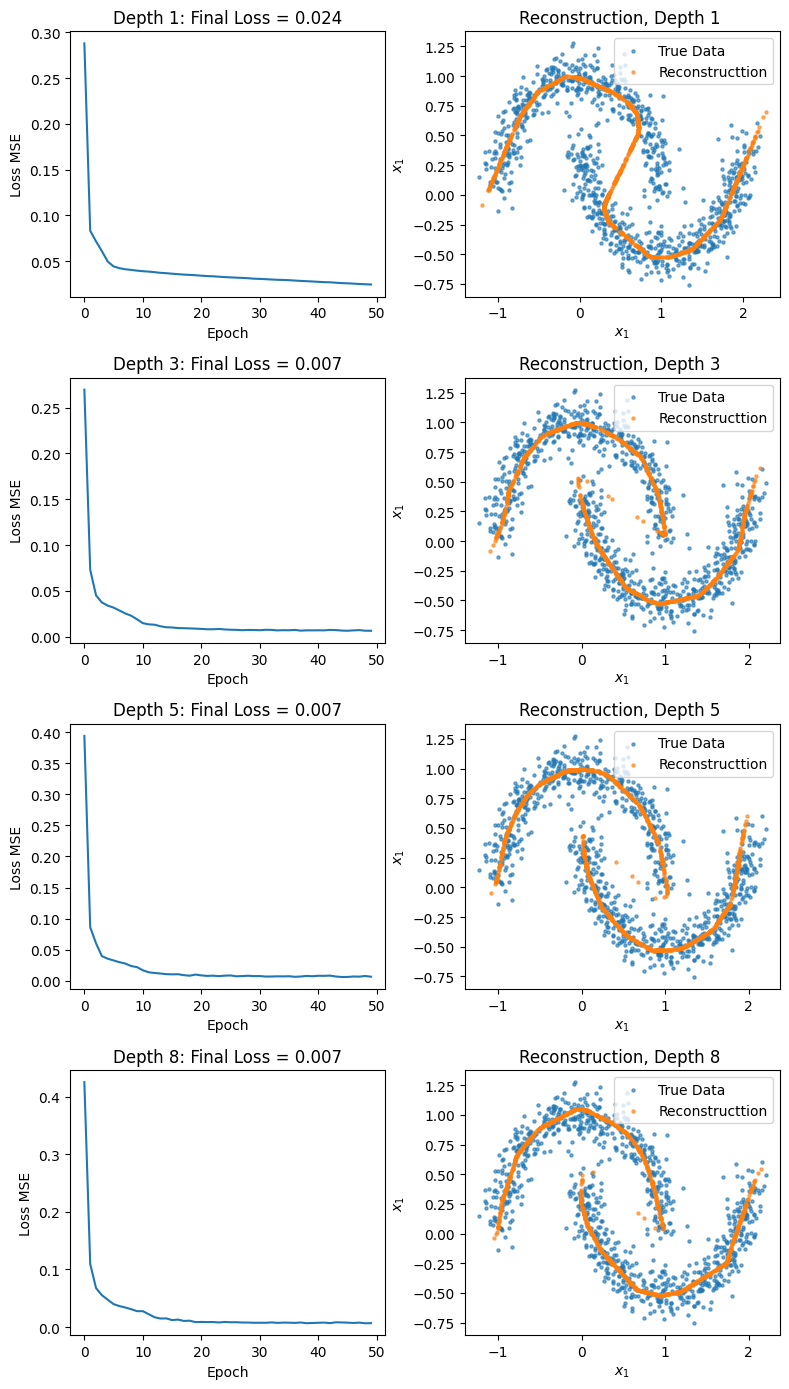

In [13]:
# --- NETWORK DEPTH ---
in_features=2
bottleneck_size=1 
hidden_sizes=32
hidden_layers=[1, 3, 5, 8]

epochs = 50

fig, axs = plt.subplots(4, 2, figsize =(8, 14))

for i, depth in enumerate(hidden_layers):
    model_n = Autoencoder(in_features, bottleneck_size, hidden_size, depth)
    
    # --- start trianing loop ---
    print(f"---- Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={hidden_size}, hidden_layers={depth}) ----")
    
    # get time (interesting)
    t_start = time.time()

    _, loss = train_autoecoder(model_n, X_train, epochs)

    t_end = time.time()
    elapsed = t_end - t_start
    dt = time.strftime('%M:%S', time.gmtime(elapsed))
    print(f"Time elapsed: {dt}.")

    # plot using helper
    plot_MSELoss_epoch(loss, epochs, f"Depth {depth}: Final Loss = {np.round(loss[-1],3)}", axs[i, 0])

    # --- reconstruct and visualize ---
    with torch.no_grad():
        encoded_val, decoded = model_n(torch.as_tensor(X_val, dtype=torch.float32, device=device))
        reconstructed = decoded.cpu().numpy()

    plot_data_reconstruction(X_val, reconstructed, f"Reconstruction, Depth {depth} ", axs[i, 1])
    print("\n")
plt.tight_layout()
plt.show()

Increasing network depth increases computation time, while the actual quality of the reconstruction gets only marginally better. We settle for a medium layer size just to be careful.

---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
Epoch 10/50, Loss: 0.0268
Epoch 20/50, Loss: 0.0345
Epoch 30/50, Loss: 0.1099
Epoch 40/50, Loss: 0.0247
Epoch 50/50, Loss: 0.0182
Time elapsed: 00:35.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
Epoch 10/50, Loss: 0.0253
Epoch 20/50, Loss: 0.0078
Epoch 30/50, Loss: 0.0067
Epoch 40/50, Loss: 0.0066
Epoch 50/50, Loss: 0.0059
Time elapsed: 00:33.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
Epoch 10/50, Loss: 0.0802
Epoch 20/50, Loss: 0.0403
Epoch 30/50, Loss: 0.0356
Epoch 40/50, Loss: 0.0323
Epoch 50/50, Loss: 0.0281
Time elapsed: 00:31.


---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
Epoch 10/50, Loss: 0.5691
Epoch 20/50, Loss: 0.5167
Epoch 30/50, Loss: 0.2761
Epoch 40/50, Loss: 0.2054
Epoch 50/50, Loss: 0.1630
Time elapsed: 00:32.




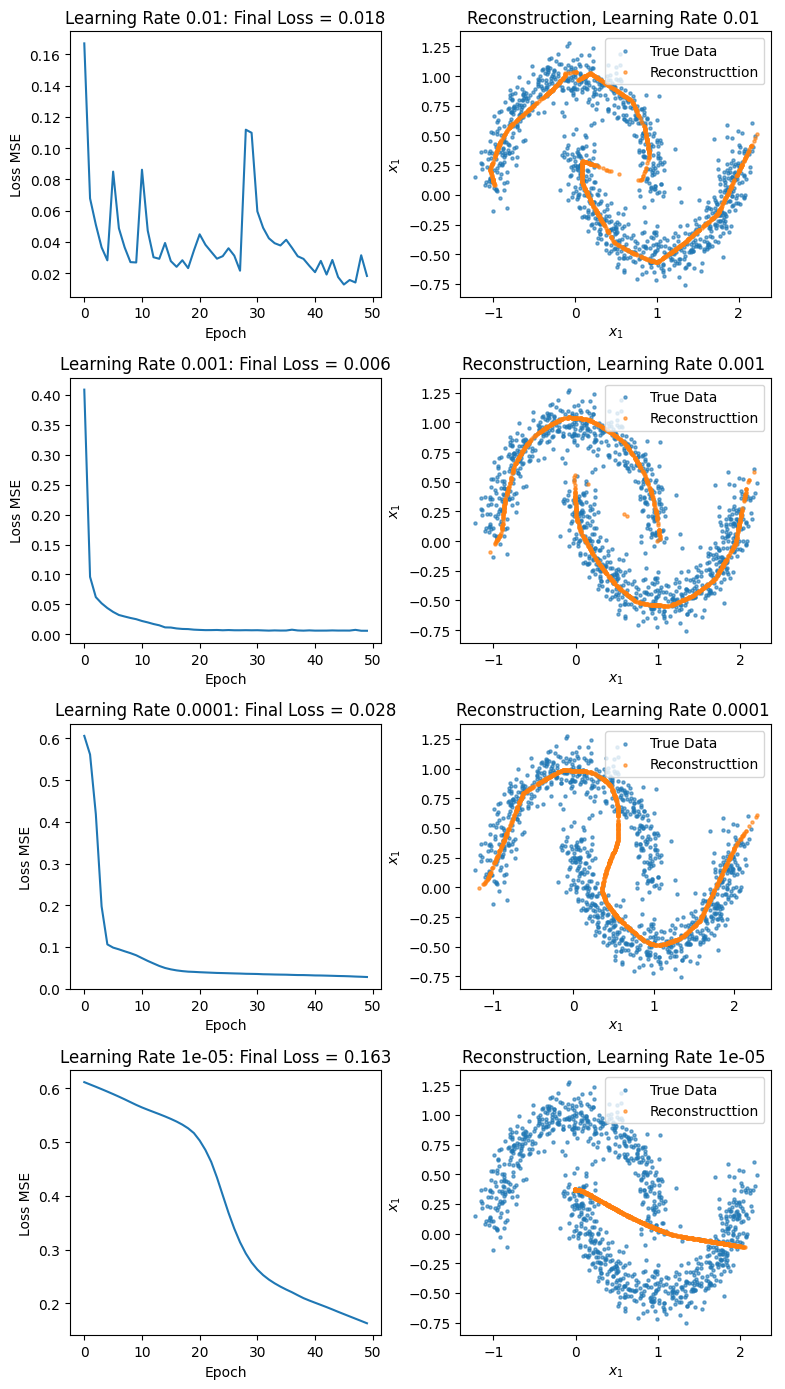

In [14]:
# ---  LEARNING RATE ---
in_features=2
bottleneck_size=1 
hidden_sizes=32
hidden_layers=5

epochs = 50

learning_rates = [1e-2, 1e-3, 1e-4, 1e-5]

fig, axs = plt.subplots(4, 2, figsize =(8, 14))

for i, lr in enumerate(learning_rates):
    model_n = Autoencoder(in_features, bottleneck_size, hidden_size, hidden_layers)
    
    # --- start trianing loop ---
    print(f"---- Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={hidden_size}, hidden_layers={hidden_layers}) ----")
    
    # get time (interesting)
    t_start = time.time()

    _, loss = train_autoecoder(model_n, X_train, epochs, num_batches=32, learning_rate=lr)

    t_end = time.time()
    elapsed = t_end - t_start
    dt = time.strftime('%M:%S', time.gmtime(elapsed))
    print(f"Time elapsed: {dt}.")

    # plot using helper
    plot_MSELoss_epoch(loss, epochs, f"Learning Rate {lr}: Final Loss = {np.round(loss[-1],3)}", axs[i, 0])

    # --- reconstruct and visualize ---
    with torch.no_grad():
        encoded_val, decoded = model_n(torch.as_tensor(X_val, dtype=torch.float32, device=device))
        reconstructed = decoded.cpu().numpy()

    plot_data_reconstruction(X_val, reconstructed, f"Reconstruction, Learning Rate {lr} ", axs[i, 1])
    print("\n")
plt.tight_layout()
plt.show()

Too high of a learning rate makes the network pretty uncertain where to go, while a low one does not allow sufficiently fast adaption to capture the models in otherwise good epoch length. The default learning rate actually produces the best outcome rigth of the bat.

We conclude that a network of the following structure performs very well while being computationally efficient in Task 1:

    Autoencoder(input_dim=2, bottleneck=1, hidden_size=32, layers=5)

while training on about 50 epochs with standard minibatching and learning rate.

#### Histogram and Sampling from GMM 

<div style="color: green; font-weight:
bold">

The implementation is equivalent to the solution. It fits the GMM with 8 components and plots the histogram. 2 modes are visible in the encoded data and the generated samples fit the two moons well.

</div>

In [15]:
# settle for fine hyperparams
in_features=2
bottleneck_size=1 
hidden_size=32
hidden_layers=5

epochs = 50
N_samples = 5000

model = Autoencoder(in_features, bottleneck_size, hidden_size, hidden_layers)

X, y = datasets.make_moons(N_samples, random_state=42, noise=0.1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model_trained, loss = train_autoecoder(model, X_train, epochs)

Epoch 10/50, Loss: 0.0183
Epoch 20/50, Loss: 0.0098
Epoch 30/50, Loss: 0.0072
Epoch 40/50, Loss: 0.0069
Epoch 50/50, Loss: 0.0070


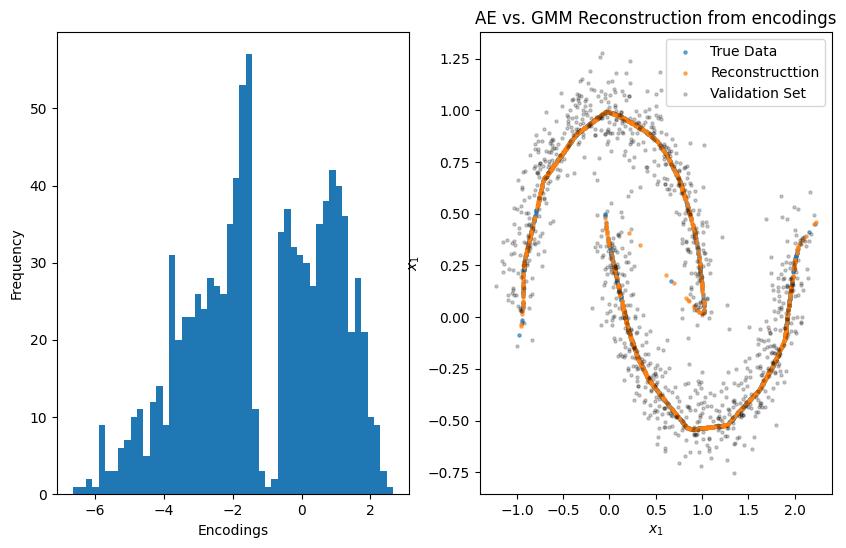

In [16]:
# get encodings from model
with torch.no_grad():
    encoded_val, decoded = model(torch.as_tensor(X_val, dtype=torch.float32, device=device))
    encodings = encoded_val.cpu().numpy()
    reconstructions = decoded.cpu().numpy()

# fit GMM (K=8 from last sheet was good result)
gmm_8 = GaussianMixture(8) 
gmm_8.fit(encodings)
gmm_samples = gmm_8.sample(reconstructions.shape[0]) # encodings sampled from GMM

# decode artificial encodings to artificial reconstruction
with torch.no_grad():
    gmm_decoded = model.decoder(torch.as_tensor(gmm_samples[0], dtype=torch.float32, device=device))
    gmm_rec = gmm_decoded.cpu().numpy()

#visuals
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
axs = axs.flatten()
axs[0].hist(encodings, bins=50)
axs[0].set_xlabel("Encodings")
axs[0].set_ylabel("Frequency")


plot_data_reconstruction(reconstructions, gmm_rec, "AE vs. GMM Reconstruction from encodings", axs[1])
axs[1].scatter(X_val[:, 0], X_val[:, 1], label="Validation Set", s=5, alpha=0.2, c="black")
axs[1].legend()

We see that the encodings occur in two distinct modes, roughly $z<-1$  and $z>-1$. That is suitable for the task and also well reflected in the reconstruction (orange), which is by eye indistinguishable from the True Data Reconstruction (blue), which both follow the validation data (black).

#### Results on different Training Sets

<div style="color: green; font-weight:
bold">

1.2 Retraining with same & different data sets

They combine retraining with the same and different training sets and conclude that the AE delivers very similar results throughout. They also show that small inaccuracies in the training process can lead to few very different results.

The submission is equivalent to the solution.
</div>

---- Testset 1: Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
## Run 1 ##
Epoch 10/50, Loss: 0.0222
Epoch 20/50, Loss: 0.0114
Epoch 30/50, Loss: 0.0083
Epoch 40/50, Loss: 0.0067
Epoch 50/50, Loss: 0.0091
Time elapsed: 00:33.


## Run 2 ##
Epoch 10/50, Loss: 0.0067
Epoch 20/50, Loss: 0.0064
Epoch 30/50, Loss: 0.0082
Epoch 40/50, Loss: 0.0067
Epoch 50/50, Loss: 0.0068
Time elapsed: 00:32.


---- Testset 2: Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
## Run 1 ##
Epoch 10/50, Loss: 0.0062
Epoch 20/50, Loss: 0.0059
Epoch 30/50, Loss: 0.0377
Epoch 40/50, Loss: 0.0219
Epoch 50/50, Loss: 0.0082
Time elapsed: 00:32.


## Run 2 ##
Epoch 10/50, Loss: 0.0068
Epoch 20/50, Loss: 0.0062
Epoch 30/50, Loss: 0.0061
Epoch 40/50, Loss: 0.0063
Epoch 50/50, Loss: 0.0060
Time elapsed: 00:32.


---- Testset 3: Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
## Run 1 ##
Epoch 10/50, Loss: 0.0061
Epoch 20/50, Loss: 0.0066
Epoch 

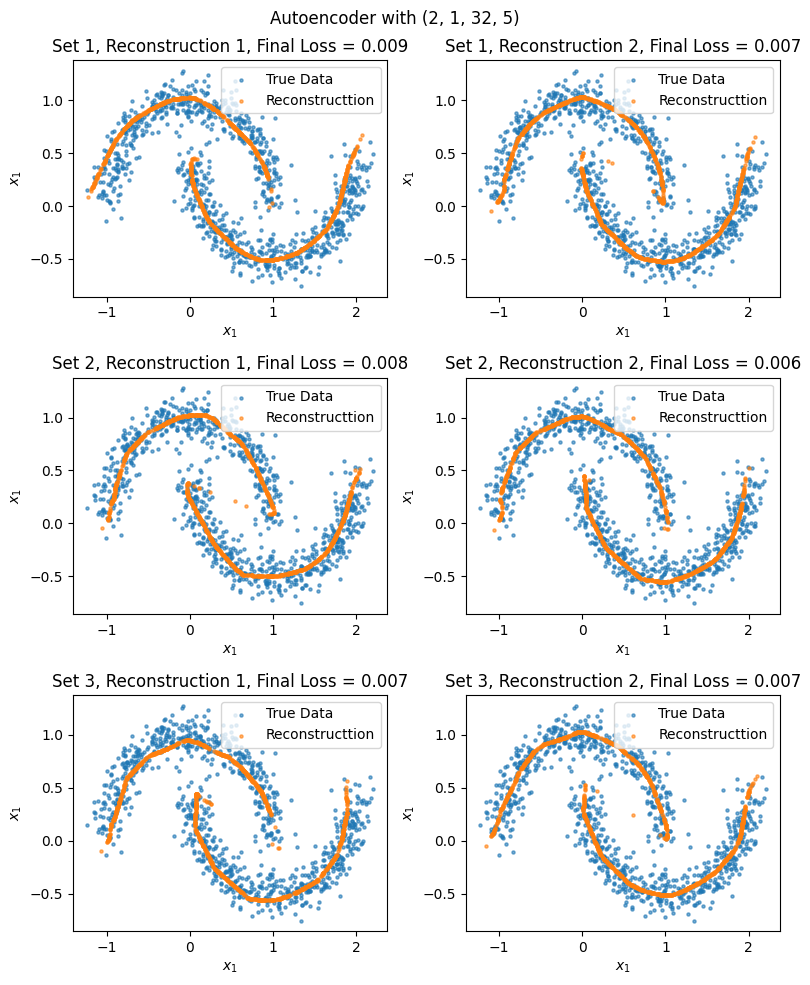

In [17]:
# settle for fine hyperparams
in_features=2
bottleneck_size=1 
hidden_size=32
hidden_layers=5

epochs = 50
N_samples = 5000

model = Autoencoder(in_features, bottleneck_size, hidden_size, hidden_layers)

fig, axs = plt.subplots(3, 2, figsize =(8, 10))
fig.suptitle(f"Autoencoder with {(in_features, bottleneck_size, hidden_size, hidden_layers)}")

for j in range(3):
    # generate each a training and validation sets of size 5000
    X, y = datasets.make_moons(N_samples, random_state=42, noise=0.1)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"---- Testset {j+1}: Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={hidden_size}, hidden_layers={hidden_layers}) ----")
    
    # run each test set twice to look for differences
    for k in range(2):
        # --- start trianing loop ---
        # get time (interesting)
        t_start = time.time()
        print(f"## Run {k+1} ##")
        _, loss = train_autoecoder(model, X_train, epochs)

        t_end = time.time()
        elapsed = t_end - t_start
        dt = time.strftime('%M:%S', time.gmtime(elapsed))
        print(f"Time elapsed: {dt}.")

        # --- reconstruct and visualize ---
        with torch.no_grad():
            encoded_val, decoded = model(torch.as_tensor(X_val, dtype=torch.float32, device=device))
            reconstructed = decoded.cpu().numpy()

        plot_data_reconstruction(X_val, reconstructed, 
                                f"Set {j+1}, Reconstruction {k+1}, Final Loss = {np.round(loss[-1], 3)}", ax=axs[j, k])
        print("\n")

plt.tight_layout()
plt.show()
    

Most of the time, the Reconstruction is very very similar, but here and there the curves change shape. This is as possible as the gradient descent in training or similar minor changes may strongly change the curve and losses creating a cascade of small changes. Generally though, the results are quite good throughout.
This effect would be greater on less well trained AEs.

<div style="color: green; font-weight:
bold">

1.4 Test set with noise 0.2, but no re-training

The solution is equivalent.

</div>

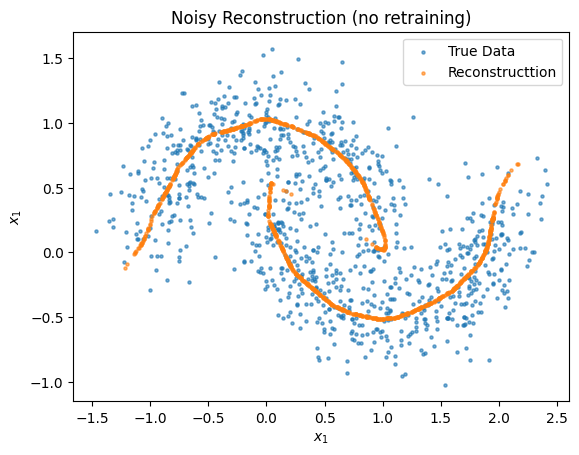

In [18]:
# create new set using noise 0.2, but no retraining!
X2, y2 = datasets.make_moons(N_samples, random_state=42, noise=0.2)
X_train_noisy, X_val_noisy, y_train_noisy, y_val_noisy = train_test_split(X2, y2, test_size=0.2, random_state=42)

with torch.no_grad():
    encoded_val_noisy, decoded_noisy = model(torch.as_tensor(X_val_noisy, dtype=torch.float32, device=device))
    reconstructed_noisy = decoded_noisy.cpu().numpy()


plot_data_reconstruction(X_val_noisy, reconstructed_noisy, 
                            f"Noisy Reconstruction (no retraining)")

We see how the encoder struggles to mimic it perfectly - instead it gets more "wobbly" - but still remains somewhat similar to other curves seen before. That is, because we trained on non-noisy data and the AE tries to find the pattern (which is close to the two moons when not not noisy) as best as possible for the noisy data, but the noise makes the distinction significantly harder.

<div style="color: green; font-weight:
bold">

1.5 Re-training on noise 0.2

The implementation is equivalent to the solution. It does not create a space-filling curve, but the greater variance in the MSE loss shows the autoencoder 'struggling' to properly fit the noisy data. 

</div>

---- Trainig AE(in_size=2, bottleneck=1, hidden_size=32, hidden_layers=5) ----
Epoch 10/50, Loss: 0.0314
Epoch 20/50, Loss: 0.0391
Epoch 30/50, Loss: 0.0489
Epoch 40/50, Loss: 0.0298
Epoch 50/50, Loss: 0.0295
Time elapsed: 00:32.




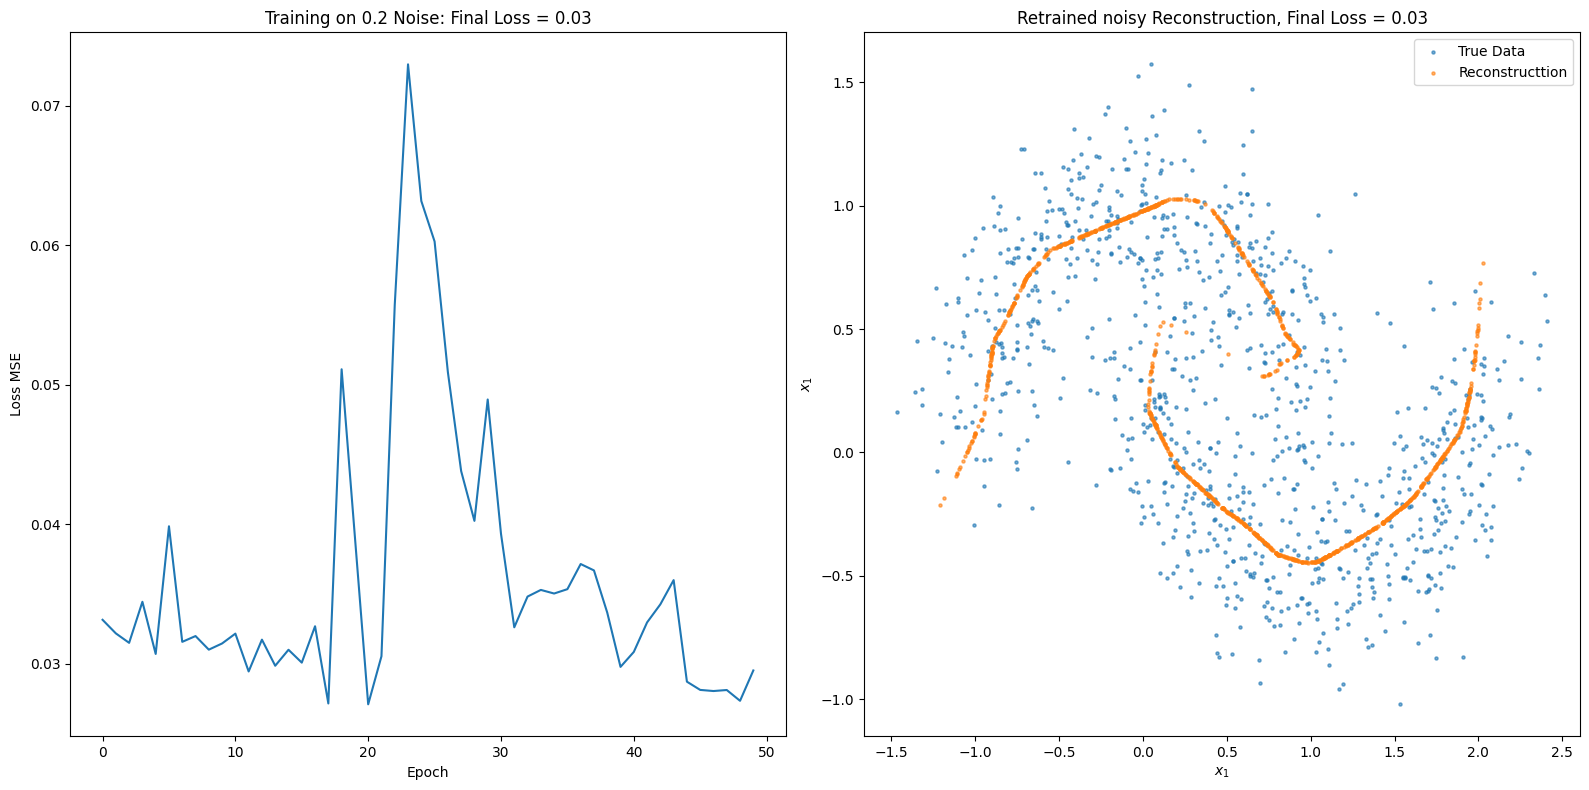

In [19]:
### RETRAIN ON NOISY DATA ###
fig, axs = plt.subplots(1, 2, figsize=(16,8))

# --- start trianing loop ---
print(f"---- Trainig AE(in_size={in_features}, bottleneck={bottleneck_size}, hidden_size={hidden_size}, hidden_layers={hidden_layers}) ----")

# get time (interesting)
t_start = time.time()

# here retraining happens
_, loss = train_autoecoder(model, X_train_noisy, epochs)

t_end = time.time()
elapsed = t_end - t_start
dt = time.strftime('%M:%S', time.gmtime(elapsed))
print(f"Time elapsed: {dt}.")

# plot using helper (not necessary here)
plot_MSELoss_epoch(loss, epochs, f"Training on 0.2 Noise: Final Loss = {np.round(loss[-1],3)}", ax=axs[0])

# --- reconstruct and visualize ---
with torch.no_grad():
    encoded_val, decoded = model(torch.as_tensor(X_val_noisy, dtype=torch.float32, device=device))
    reconstructed = decoded.cpu().numpy()


plot_data_reconstruction(X_val_noisy, reconstructed, 
                            f"Retrained noisy Reconstruction, Final Loss = {np.round(loss[-1], 3)}", ax=axs[1])
print("\n")

plt.tight_layout()
plt.show()

We see how the AE now struggles to properly learn the data with previously good parameters. Also, in the reconstruction, the lines gets smeared out more. That is the spacefilling curve behaviour we expect in order to minimize a noisy data set.

----

## Task 2

In [20]:
# Similar to last week
def MMD2Loss(x, y, kernel_bandwidth=1.0):
    # Compute pairwise squared distances
    x_norm = (x ** 2).sum(dim=1).unsqueeze(1)  # (n_x, 1)
    y_norm = (y ** 2).sum(dim=1).unsqueeze(1)  # (n_y, 1)
    K_xx = kernel_bandwidth / (kernel_bandwidth + x_norm + x_norm.t() - 2 * x @ x.t())
    K_yy = kernel_bandwidth / (kernel_bandwidth + y_norm + y_norm.t() - 2 * y @ y.t())
    K_xy = kernel_bandwidth / (kernel_bandwidth + x_norm + y_norm.t() - 2 * x @ y.t())

    mmd2 = K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()
    return mmd2

In [21]:
def plot_code_reconstruction_generated(model, X_val, ax=None, n_samples=500):
    if ax is None:
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    with torch.no_grad():
        encodings, decoded = model(torch.as_tensor(X_val, dtype=torch.float32, device=device))
        codes = encodings.cpu().numpy()
        reconstructions = decoded.cpu().numpy()
    
    # 1. Scatter of encodings
    ax[0].scatter(codes[:, 0], codes[:, 1], alpha=0.6, s=5)
    ax[0].set_xlabel(f"$z_1$")
    ax[0].set_ylabel(f"$z_2$")
    ax[0].set_title('Encodings')
    
    # 2. Scatter of reconstruction vs. X_val
    ax[1].scatter(X_val[:, 0], X_val[:, 1], label="True Data", alpha=0.5, s=5)
    ax[1].scatter(reconstructions[:, 0], reconstructions[:, 1], label="Reconstruction", alpha=0.5, s=5)
    ax[1].set_xlabel("$x_1$")
    ax[1].set_ylabel("$x_2$")
    ax[1].set_title("Reconstruction vs. True Data")
    ax[1].legend(loc='best')
    
    # 3. Decode samples from standard normal
    latent_dim = codes.shape[1]
    z_samples = torch.randn(n_samples, latent_dim, device=device)
    with torch.no_grad():
        gen_decoded = model.decoder(z_samples)
        gen_reconstructions = gen_decoded.cpu().numpy()
    ax[2].scatter(gen_reconstructions[:, 0], gen_reconstructions[:, 1], alpha=0.5, s=5, label="Generated")
    ax[2].set_xlabel("$x_1$")
    ax[2].set_ylabel("$x_2$")
    ax[2].set_title("Decoded Standard Normal Samples")
    ax[2].legend(loc='best')
    
    return ax


In [22]:
### TRAIN ON MMD2 ###
def train_autoecoder_mmd2(model, train_data, num_epochs, beta=1.0, num_batches=32, learning_rate=0.001,
                          kernel_bw = 1.0, store_epochs=False, epoch_list=None):
    
    # convert all data to torch.tensor object if it has not happened
    if not isinstance(train_data, torch.Tensor):
        train_data = torch.Tensor(train_data)
    train_data.to(device)
    
    data_loader = DataLoader(train_data, batch_size=num_batches, shuffle=True)
    
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # we store two losses now, and their weighted sum
    losses = []
    mse_losses = []
    mmd_losses = []
    
    for epoch in range(1, num_epochs + 1):
        epoch_loss = 0.0
        epoch_mse = 0.0
        epoch_mmd = 0.0
        for batch in data_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            codes, decoded = model(batch)

            # for the mmd2, sample codes from prior (here N(0, 1)), 
            # compare them to the codes from model
            sample_codes = torch.randn_like(codes).to(device)
            loss_mmd = MMD2Loss(codes, sample_codes, kernel_bandwidth=kernel_bw)

            # rest is the same
            loss_mse = nn.MSELoss()(decoded, batch)
            loss = loss_mse + beta * loss_mmd
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch.size(0)
            epoch_mse += loss_mse.item() * batch.size(0)
            epoch_mmd += loss_mmd.item() * batch.size(0)

        avg_loss = epoch_loss / len(train_data)
        avg_mse = epoch_mse / len(train_data)
        avg_mmd = epoch_mmd / len(train_data)
        losses.append(avg_loss)
        mse_losses.append(avg_mse)
        mmd_losses.append(avg_mmd)
        
        if (epoch) % 10 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Loss: {avg_loss:.6f}, MSE: {avg_mse:.6f}, β * MMD^2: {beta * avg_mmd:.6f}")

        # a try for a logic to store over multiple epoch instances
        # to save computational time
        if store_epochs == True:
            if epoch in epoch_list:
                plot_idx = epoch_list.index(epoch)
                plot_code_reconstruction_generated(model, X_val, ax=axs[plot_idx])
                axs[plot_idx, 0].set_title(f"Encodings (Epoch {epoch})")
                axs[plot_idx, 1].set_title(f"Reconstruction (Epoch {epoch}), L={avg_loss:.6f}")
                axs[plot_idx, 2].set_title(f"Generated (Epoch {epoch})")
            
    return model, losses, mse_losses, mmd_losses

Here we tried a lot to adjsut hyperparams for somewhat reasonable results. The first one is below, later a similar, but deeper ResNet is tested.

Findings:
- The most important was a lower kernel bandwidth for the MMD^2 computation, with the default of 1, we had no real adjustment in the latent space;
- We have a smaller $\beta$, which means a slightly lower importance on the MMD^2. That however is only a little less then 1, so nothing too fancy;
- The rest of the hyperparams are close to our experiences from task 1.

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
) 

Epoch 10/200, Loss: 0.064273, MSE: 0.000705, β * MMD^2: 0.063568
Epoch 20/200, Loss: 0.061500, MSE: 0.000673, β * MMD^2: 0.060827
Epoch 30/200, Loss: 0.060702, MSE: 0.000721, β * MMD^2: 0.059981
Epoch 40/200, Loss: 0.060844, MSE: 0.000795, β * MMD^2: 0.060049
Epoch 50/200, Loss: 0.059960, MSE: 0.000707, β * MMD^2: 0.059253
Epoch 60/200, Loss: 0.060725, MSE: 0.000679, β * MMD^2: 0.060047
Epoch 70/200, Loss: 0.059616, MSE: 0.000733, β * MMD^2: 0.058883
Epoch 80/200, Loss: 0.057753, MSE: 0.000787, β * M

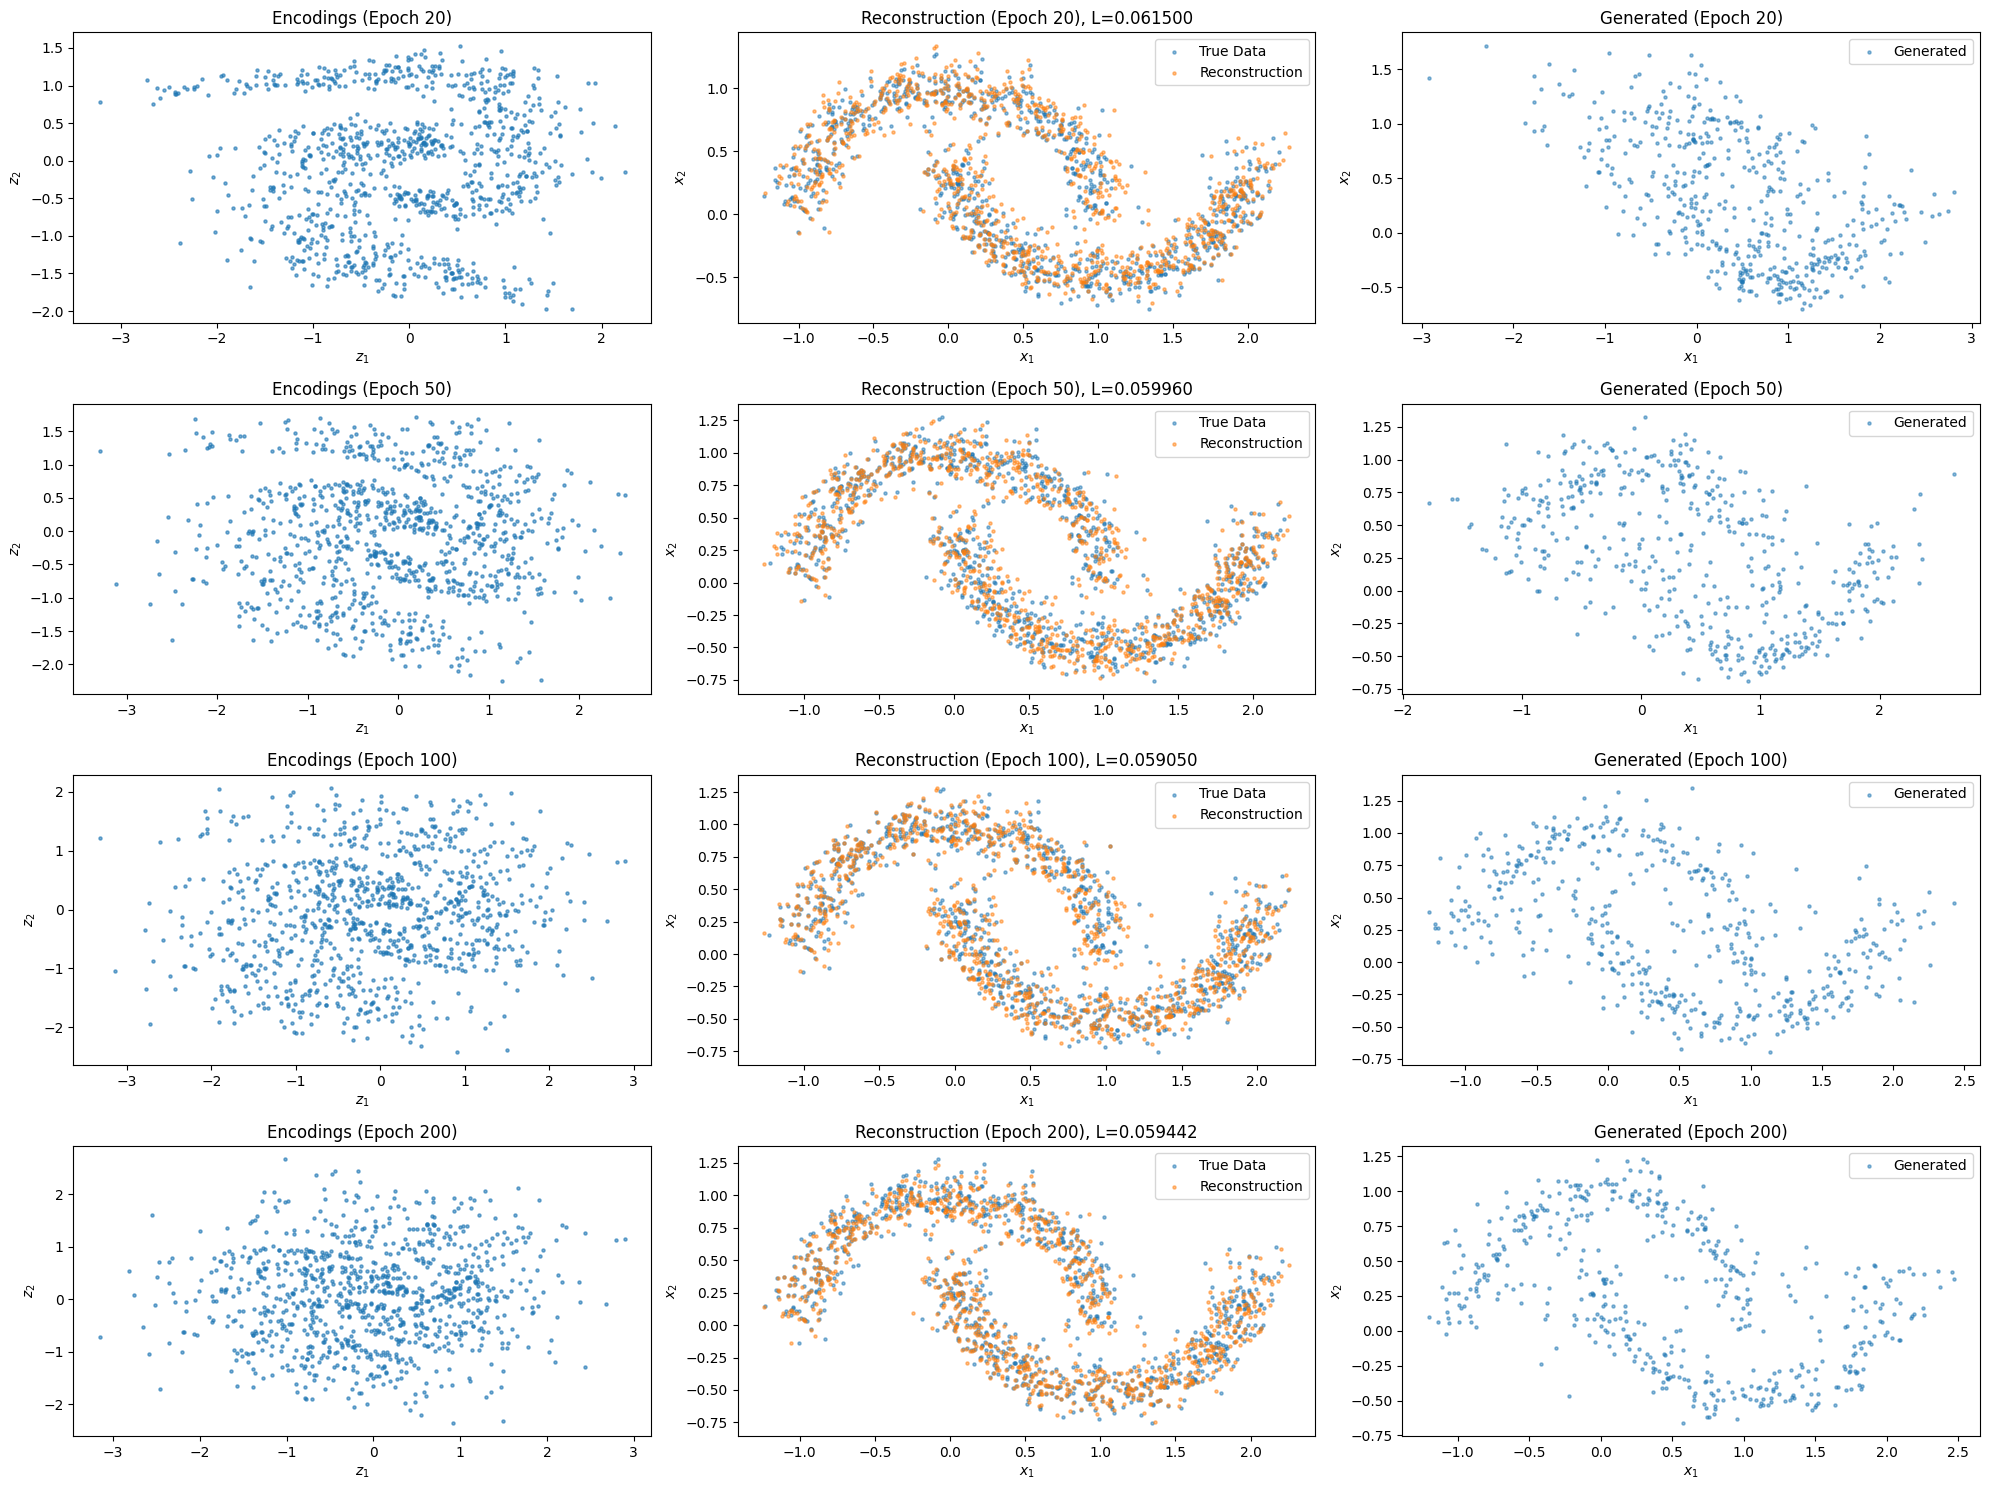

In [23]:
# indicated by task: dim hidden 50 >> 2, 2 layers
ResNet = Autoencoder(input_size=2, bottleneck_size=2, hidden_size=50, layers=2) 
print(ResNet, "\n")

# check here and there how it performs to track learning
epochs_list = [20, 50, 100, 200]

fig, axs = plt.subplots(len(epochs_list), 3, figsize=(20, 15))

t_start = time.time()
_, losses, losses_mse, losses_mmd2 = train_autoecoder_mmd2(ResNet, X_train, num_epochs=epochs_list[-1], beta=1,
                                                                num_batches=32, learning_rate=1e-3,
                                                                kernel_bw=0.1,
                                                                store_epochs=True, epoch_list=epochs_list)

t_end = time.time()
elapsed = t_end - t_start
dt = time.strftime('%M:%S', time.gmtime(elapsed))
print(f"Time elapsed: {dt}.")

plt.tight_layout()
plt.show()


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
) 

Epoch 10/200, Loss: 0.03364

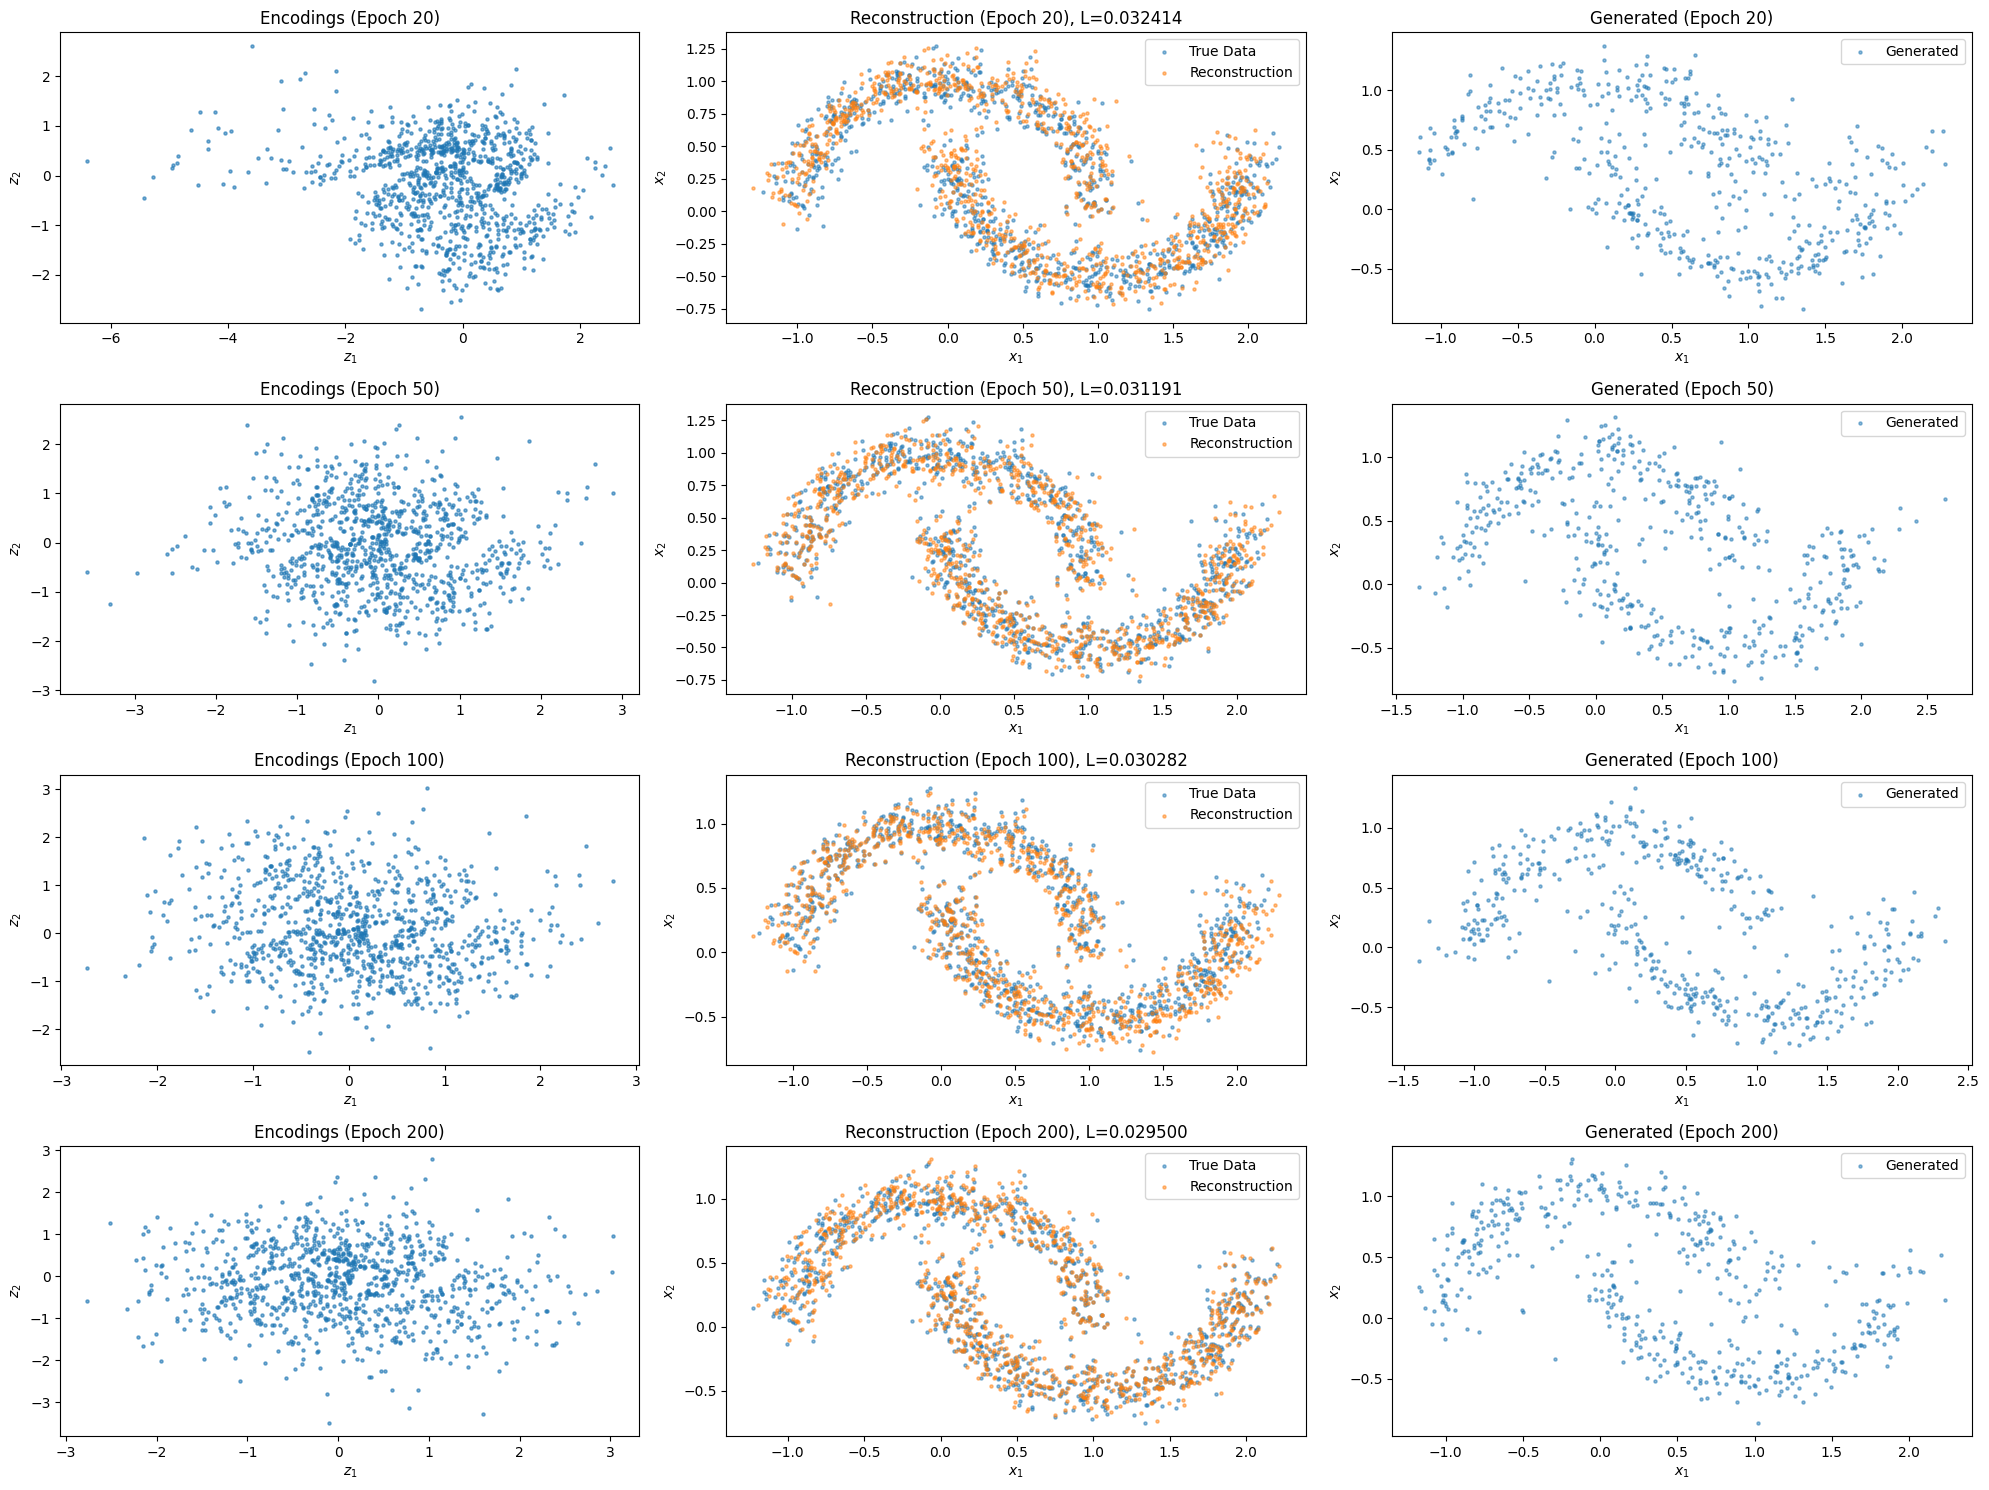

In [24]:
ResNet2 = Autoencoder(input_size=2, bottleneck_size=2, hidden_size=128, layers=5) 
print(ResNet2, "\n")


fig, axs = plt.subplots(len(epochs_list), 3, figsize=(20, 15))

t_start = time.time()
_, losses, losses_mse, losses_mmd2 = train_autoecoder_mmd2(ResNet2, X_train, num_epochs=epochs_list[-1], beta=0.5,
                                                                num_batches=32, learning_rate=1e-3,
                                                                kernel_bw=0.11,
                                                                store_epochs=True, epoch_list=epochs_list)

t_end = time.time()
elapsed = t_end - t_start
dt = time.strftime('%M:%S', time.gmtime(elapsed))
print(f"Time elapsed: {dt}.")

plt.tight_layout()
plt.show()

Generally, we see how first there are again distinct modes in the latent space. The reconstruction of validation data was good, but using a synthetic data set sampled from a standard normal gave very poor results. Through MMD^2 loss though, we enforced that the model learns how to best create codes close to the standard normal that in the end still yield a good reconstruction with both the validation set, but now also with synthetic data generated by a standard normal too.

We observe how the latent distribution approaches a standard normal, ehile the reconstruction is closer and closer to the two moons. However, we still see modes at the last epoch and noisy synthetic reconstruction, which indicates further improvement might be possible.

----

### Task 3

In [25]:
digits = datasets.load_digits()
X_digits_train, X_digits_val, y_digits_train, y_digits_val = train_test_split(digits.data, digits.target,
                                                                               test_size=0.2, random_state=42)

input_dim=digits.data.shape[1]
hidden_size=128                #ensure higher then input dim
bottlenecks_list = [2, 4, 8]
hidden_layers=5

num_epochs=200 # higher just to be sure

# dictonaries to only train once and access info later too
models = {}
losses = {}
reconstructions = {}
codes = {}

# iterate over bottleneck sizes, init model and store model, codes, rreconstr. and losses
for bn in bottlenecks_list:
    print(f"--- Training AE with Bottleneck size {bn} ---")
    AE = Autoencoder(input_dim, bn, hidden_size, hidden_layers)
    _, loss = train_autoecoder(AE, X_digits_train, num_epochs)
    models[bn] = AE
    losses[bn] = loss
    with torch.no_grad():
        code, decoded = AE(torch.as_tensor(X_digits_val, dtype=torch.float32, device=device))
        codes[bn] = code.cpu().numpy()
        reconstructions[bn] = decoded.cpu().numpy()

--- Training AE with Bottleneck size 2 ---
Epoch 10/200, Loss: 18.3446
Epoch 20/200, Loss: 18.3398
Epoch 30/200, Loss: 18.3244
Epoch 40/200, Loss: 18.3012
Epoch 50/200, Loss: 12.2898
Epoch 60/200, Loss: 11.3539
Epoch 70/200, Loss: 10.4423
Epoch 80/200, Loss: 10.3166
Epoch 90/200, Loss: 10.1419
Epoch 100/200, Loss: 9.4271
Epoch 110/200, Loss: 10.6580
Epoch 120/200, Loss: 10.4545
Epoch 130/200, Loss: 9.5860
Epoch 140/200, Loss: 9.6344
Epoch 150/200, Loss: 9.9595
Epoch 160/200, Loss: 12.7308
Epoch 170/200, Loss: 8.9639
Epoch 180/200, Loss: 8.5373
Epoch 190/200, Loss: 9.2237
Epoch 200/200, Loss: 9.2370
--- Training AE with Bottleneck size 4 ---
Epoch 10/200, Loss: 18.3442
Epoch 20/200, Loss: 18.3291
Epoch 30/200, Loss: 18.3211
Epoch 40/200, Loss: 18.3113
Epoch 50/200, Loss: 14.5382
Epoch 60/200, Loss: 11.2556
Epoch 70/200, Loss: 10.9098
Epoch 80/200, Loss: 10.4869
Epoch 90/200, Loss: 10.1749
Epoch 100/200, Loss: 8.8544
Epoch 110/200, Loss: 7.7525
Epoch 120/200, Loss: 6.8899
Epoch 130/200, 

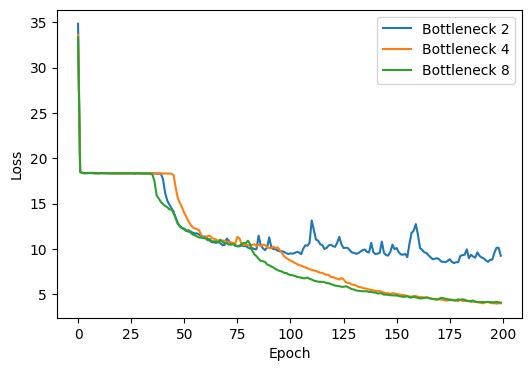

In [26]:
# Plot loss curves for all bottleneck sizes
plt.figure(figsize=(6,4))
for bn in bottlenecks_list:
    plt.plot(losses[bn], label=f"Bottleneck {bn}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

We see weird behaviour as for all we have first a massive jump, then stagnation, and then a huge jump again. In the end, loss is still high and one could argue to run longer until real convergence, but as seen below this is already quite good for a few minutes of training.

Generally, the AE_2 (indexing bn_size) performs far worse then AE_4 and AE_8, which could further improve but are equally good at 200 epochs. Interestingly, the AE_4 took longer to converge and might be the most promising model.

In [27]:
# Use classifier on reconstructions for bottleneck sizes
for bn in bottlenecks_list:
    rf = RandomForestClassifier(100, max_depth=10)
    rf.fit(X_digits_train, y_digits_train)
    y_pred_rec = rf.predict(reconstructions[bn])
    acc_rec = accuracy_score(y_digits_val, y_pred_rec)
    print(f"Accuracy on reconstructed test set (bottleneck={bn}): {acc_rec:.3f}")


Accuracy on reconstructed test set (bottleneck=2): 0.792
Accuracy on reconstructed test set (bottleneck=4): 0.947
Accuracy on reconstructed test set (bottleneck=8): 0.917


Training a RF classifier shows that all models actually perform good for the little optimization needed. While AE_2 is worst with 75%, The score roughly 90% accuracy and better which suggests good reconstruction from the codes.

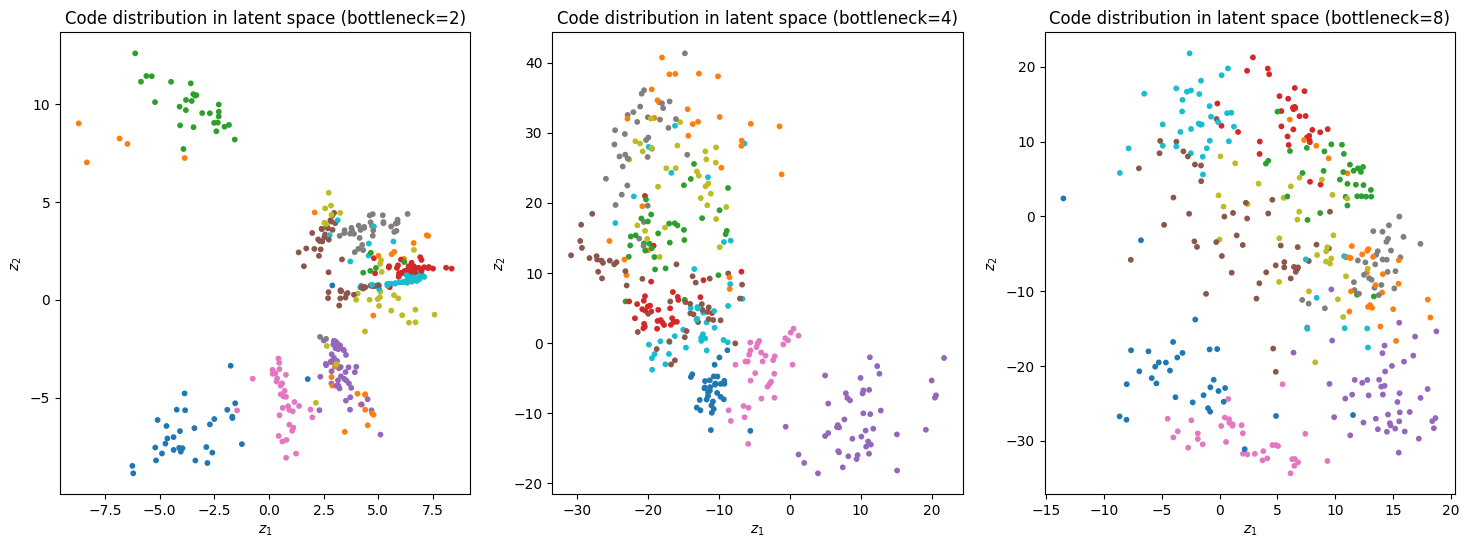

In [28]:
# Visualize code distribution by class
fig, axs = plt.subplots(1, 3, figsize=(18,6))
for i, bn in enumerate(bottlenecks_list):
    axs[i].scatter(codes[bn][:,0], codes[bn][:,1], c=y_digits_val, cmap="tab10", s=10)
    axs[i].set_title(f"Code distribution in latent space (bottleneck={bn})")
    axs[i].set_xlabel("$z_1$")
    axs[i].set_ylabel("$z_2$")

We know and see that a scatter does not capture the distribution for latent dimensions higher than 2 (there it actually works)! Thus, we need to adapt the classification and turn to more sophisticated algorithms (that sklearn supplies) such as PCA (first 2 components should suffice) or K means clustering.
But already one can identify visual classes.

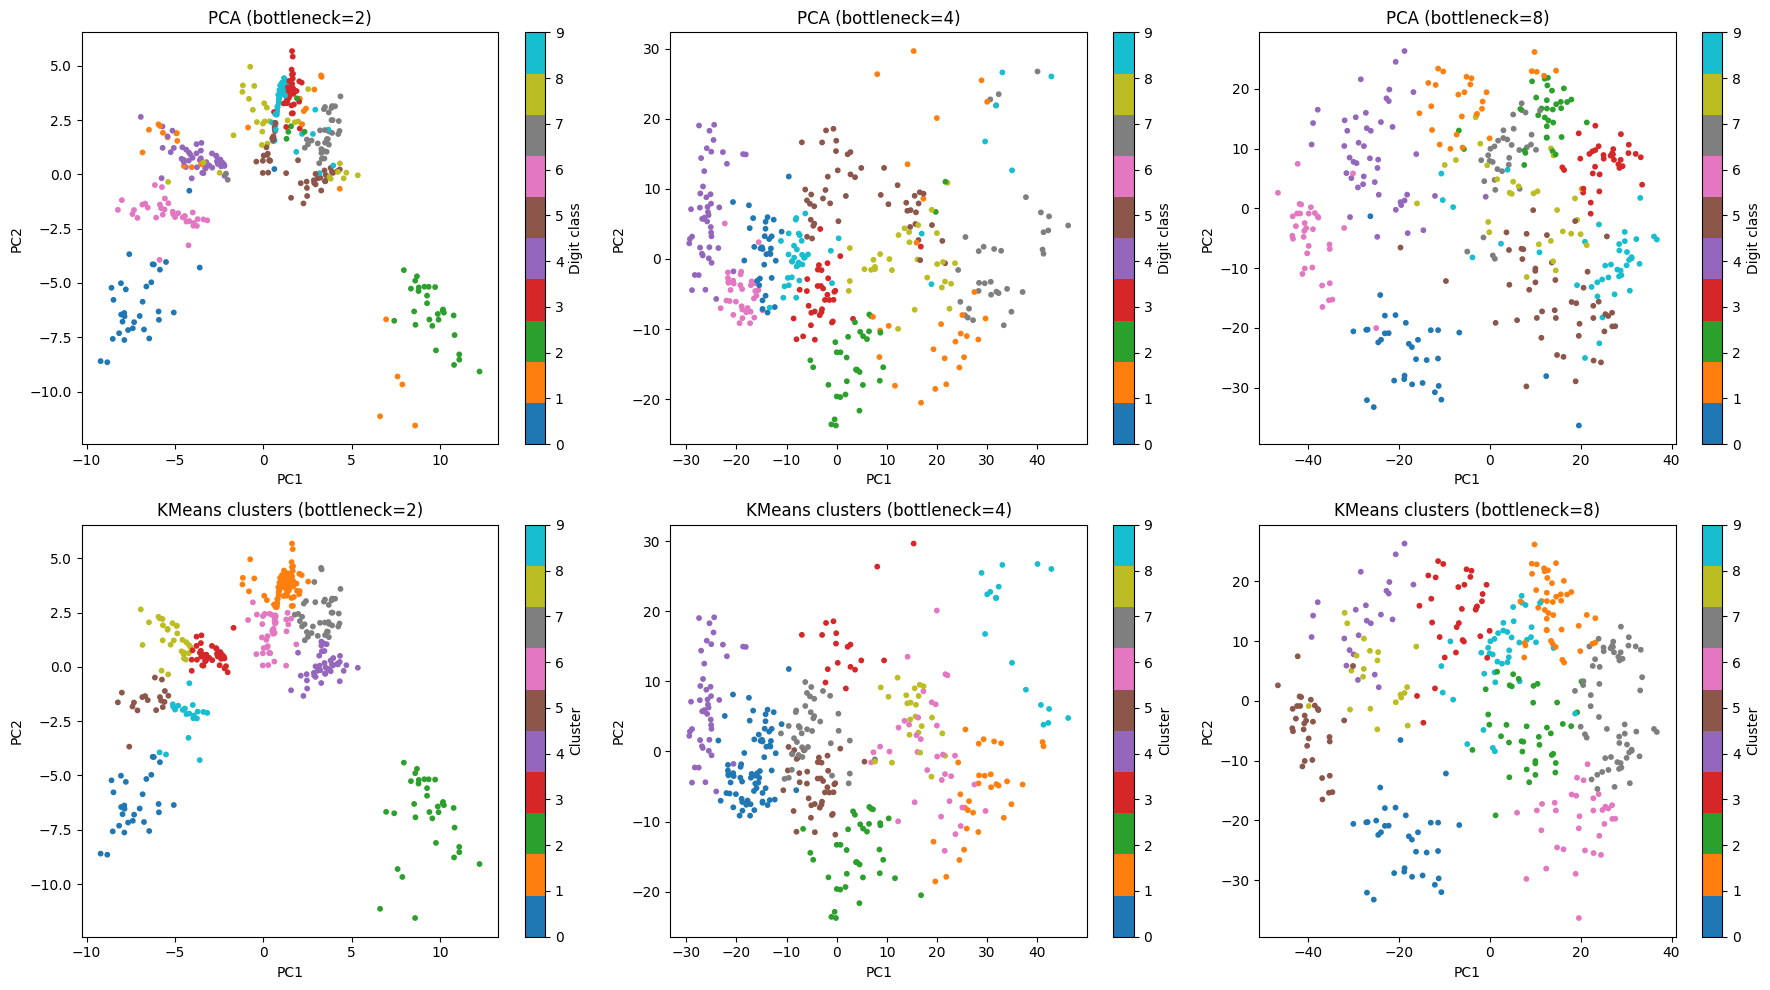

In [36]:
# visualize code distribution by class via PCA + KMEans analysis
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# we know, that we have 10 classes (cmap, clusters)
for i, bn in enumerate(bottlenecks_list):
    # PCA 1st comp.
    pca = PCA(n_components=2)
    codes_pca = pca.fit_transform(codes[bn])
    sc_pca = axs[0, i].scatter(codes_pca[:,0], codes_pca[:,1], c=y_digits_val, cmap="tab10", s=10)
    axs[0, i].set_title(f"PCA (bottleneck={bn})")
    axs[0, i].set_xlabel("PC1")
    axs[0, i].set_ylabel("PC2")
    plt.colorbar(sc_pca, ax=axs[0, i], label="Digit class")

    # (optional) KMeans clustering on PCA codes 
    n_clusters = 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(codes[bn])
    sc_kmeans = axs[1, i].scatter(codes_pca[:,0], codes_pca[:,1], c=cluster_labels, cmap="tab10", s=10)
    axs[1, i].set_title(f"KMeans clusters (bottleneck={bn})")
    axs[1, i].set_xlabel("PC1")
    axs[1, i].set_ylabel("PC2")
    plt.colorbar(sc_kmeans, ax=axs[1, i], label="Cluster")
plt.tight_layout()
plt.show()

We can see clear separation which is a good result, even for the worst models.

/Users/friedrichzeddies/venvs/py-ml/lib/python3.13/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))
/Users/friedrichzeddies/venvs/py-ml/lib/python3.13/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))
/Users/friedrichzeddies/venvs/py-ml/lib/python3.13/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


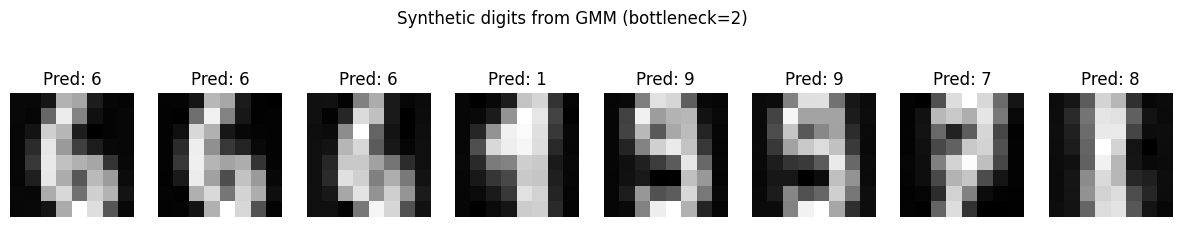

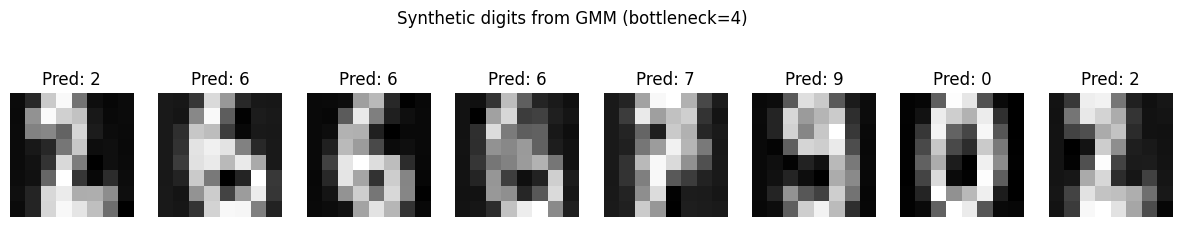

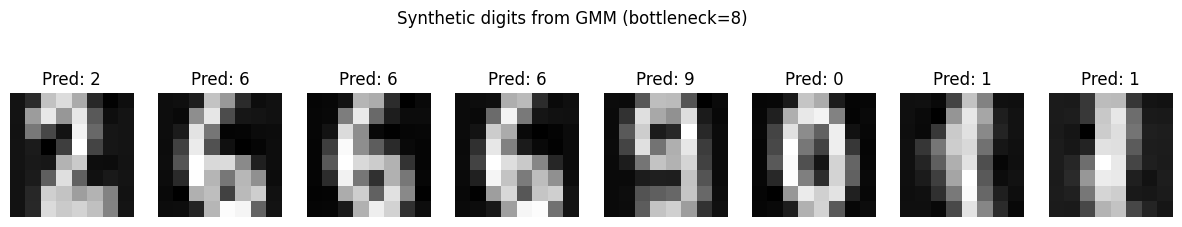

In [43]:
# fit GMMs and generate synthetic digits for all bottleneck sizes
for i, bn in enumerate(bottlenecks_list):
    AE = models[bn]

    # get codes to fit gmm to
    with torch.no_grad():
        codes_2, _ = AE(torch.as_tensor(X_digits_train, dtype=torch.float32, device=device))
        codes_2 = codes_2.cpu().numpy()

    # generate and fit gmm, K=10 
    gmm = GaussianMixture(n_components=10, random_state=42)
    gmm.fit(codes_2)
    synth_codes, _ = gmm.sample(10)

    #  feed them to decoder to generate synthetics
    with torch.no_grad():
        synth_digits = AE.decoder(torch.as_tensor(synth_codes, dtype=torch.float32, device=device)).cpu().numpy()
    
    # run rf classifier to check
    y_pred_synth = rf.predict(synth_digits)
    
    fig, axs = plt.subplots(1, 8, figsize=(15,3))
    fig.suptitle(f"Synthetic digits from GMM (bottleneck={bn})")
    for j in range(8):
        axs[j].imshow(synth_digits[j].reshape(8,8), cmap="gray")
        axs[j].axis("off")
        axs[j].set_title(f"Pred: {y_pred_synth[j]}")

We see reasonable generations (recognize digits) and actually well matching predictions, making the models all very successful throughout. 